In [1]:
import os 
import sys
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

import pandas as pd 
import numpy as np
from sklearn import tree
import graphviz
from src.model_utils import load_model, train_model, save_model, tune_model
from src.preprocessor_utils import convert_time_to_hour
from src.eval_metric import f1_benchmark, AUPRC, evaluate_model
import joblib


d:\anaconda\envs\tf_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_path = os.path.join(project_root,"data","train_goc.csv")
df = pd.read_csv(data_path)

In [3]:
test_path = os.path.join(project_root,"data",'test_goc.csv')

In [4]:
df_test = pd.read_csv(test_path)

In [5]:
x_t = df_test.drop('Class',axis = 1)
y_test = df_test['Class']

In [6]:
x = df.drop('Class', axis = 1)
y_train = df['Class']

In [7]:
preprocessor_path = os.path.join(project_root,"data","creditcard_preprocessor.pkl")
preprocessor = joblib.load(preprocessor_path)

In [8]:
x_train = preprocessor.transform(x)
x_test = preprocessor.transform(x_t)

In [9]:
opt_dc_path = os.path.join(project_root,"configs","dc_opt_raw.json")

In [10]:
rcv_dc_path = os.path.join(project_root,"configs","dc_rcv_raw.json")

In [11]:
dc_rcv_tune = tune_model(x_train,y_train,"dc","rcv",rcv_dc_path,n_iter = 50)

--- Bắt đầu Tuning DC bằng RCV ---
Fitting 5 folds for each of 50 candidates, totalling 250 fits

=== Kết quả Tuning ===
Best Params: {'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 5, 'criterion': 'gini', 'class_weight': None}
Best Score (f1): 0.8247


In [12]:
rcv_benchmark = f1_benchmark(dc_rcv_tune[0],x_test,y_test)
print(rcv_benchmark)

{'accuracy': 0.9993832164381631, 'f1': 0.7904191616766467}


In [ ]:
print(dc_rcv_tune[1])

--- ĐÁNH GIÁ: DECISIONTREE ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.88      0.71      0.78        95

    accuracy                           1.00     56746
   macro avg       0.94      0.85      0.89     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC: 0.9061
PR-AUC (AUPRC): 0.6871 (Quan trọng cho Fraud)


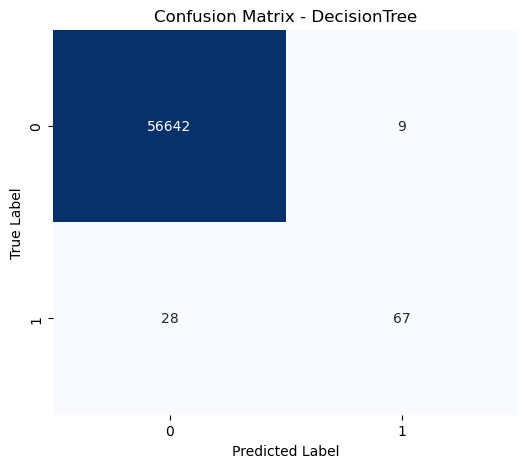

In [13]:
evaluate_model(dc_rcv_tune[0],x_test,y_test,"DecisionTree")

Kết quả từ Randomized SearchCV với model Decision Tree ta thấy được:
+ Recall là 71% nghĩa là trong tổng 95 giao dịch gian lận thì có 71% là được phát hiện, rủi ro là để bị lọt mất 29% giao dịch có thể gây thiệt hại đến tài chính hơn nhiều so với chi phí của viẹc báo nhầm với phần trăm này thì chỉ ở mức khá có thể thay đổi mô hình để nâng lên.
+ precision = 88% mang ý nghĩa là khi có thông báo gian lận thì có 88% thông báo đó là sự thật, chỉ có 12% là báo nhầm.  Đội ngũ CSKH sẽ đỡ bị quá tải vì pahir gọi điện xác minh cho khách hành oan. 
+ PR-AUC = 0,68 Điểm trung thực nhất với dự liệu bị mất cân bằng khá nặng thì con số 0.68 là khá thấp cần được cải thiện lên

In [14]:
dc_opt_tune = tune_model(x_train,y_train,"dc","optuna",opt_dc_path,n_iter = 50)

d:\PYTHON\data_mining\fraud-detecion-project\src\model_utils.py:162: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  return OptunaSearchCV(
[I 2025-12-08 21:41:32,865] A new study created in memory with name: no-name-b0a908f3-ee4e-408b-b52d-4301386db21b


--- Bắt đầu Tuning DC bằng OPTUNA ---


[I 2025-12-08 21:42:06,561] Trial 5 finished with value: 0.783804637588368 and parameters: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 17, 'ccp_alpha': 0.00030901885775012894}. Best is trial 5 with value: 0.783804637588368.
[I 2025-12-08 21:42:11,032] Trial 14 finished with value: 0.7333091285200197 and parameters: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 3, 'min_samples_split': 15, 'ccp_alpha': 0.0009894974631622856}. Best is trial 5 with value: 0.783804637588368.
[I 2025-12-08 21:42:20,796] Trial 13 finished with value: 0.7333091285200197 and parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 20, 'min_samples_split': 11, 'ccp_alpha': 0.0008455619078237666}. Best is trial 5 with value: 0.783804637588368.
[I 2025-12-08 21:42:34,881] Trial 9 finished with value: 0.7873867516768112 and parameters: {'criterion': 'entropy', 'max_depth': 9, 'min_samples_leaf': 2, 'min_samples_split': 7, 'ccp_alpha': 0.0002194


=== Kết quả Tuning ===
Best Params: {'criterion': 'entropy', 'max_depth': 14, 'min_samples_leaf': 10, 'min_samples_split': 18, 'ccp_alpha': 5.699403585183016e-05}
Best Score (f1): 0.8177


In [15]:
opt_benchmark = f1_benchmark(dc_opt_tune[0],x_test,y_test)

In [16]:
print(opt_benchmark)

{'accuracy': 0.9992951045007578, 'f1': 0.7619047619047619}


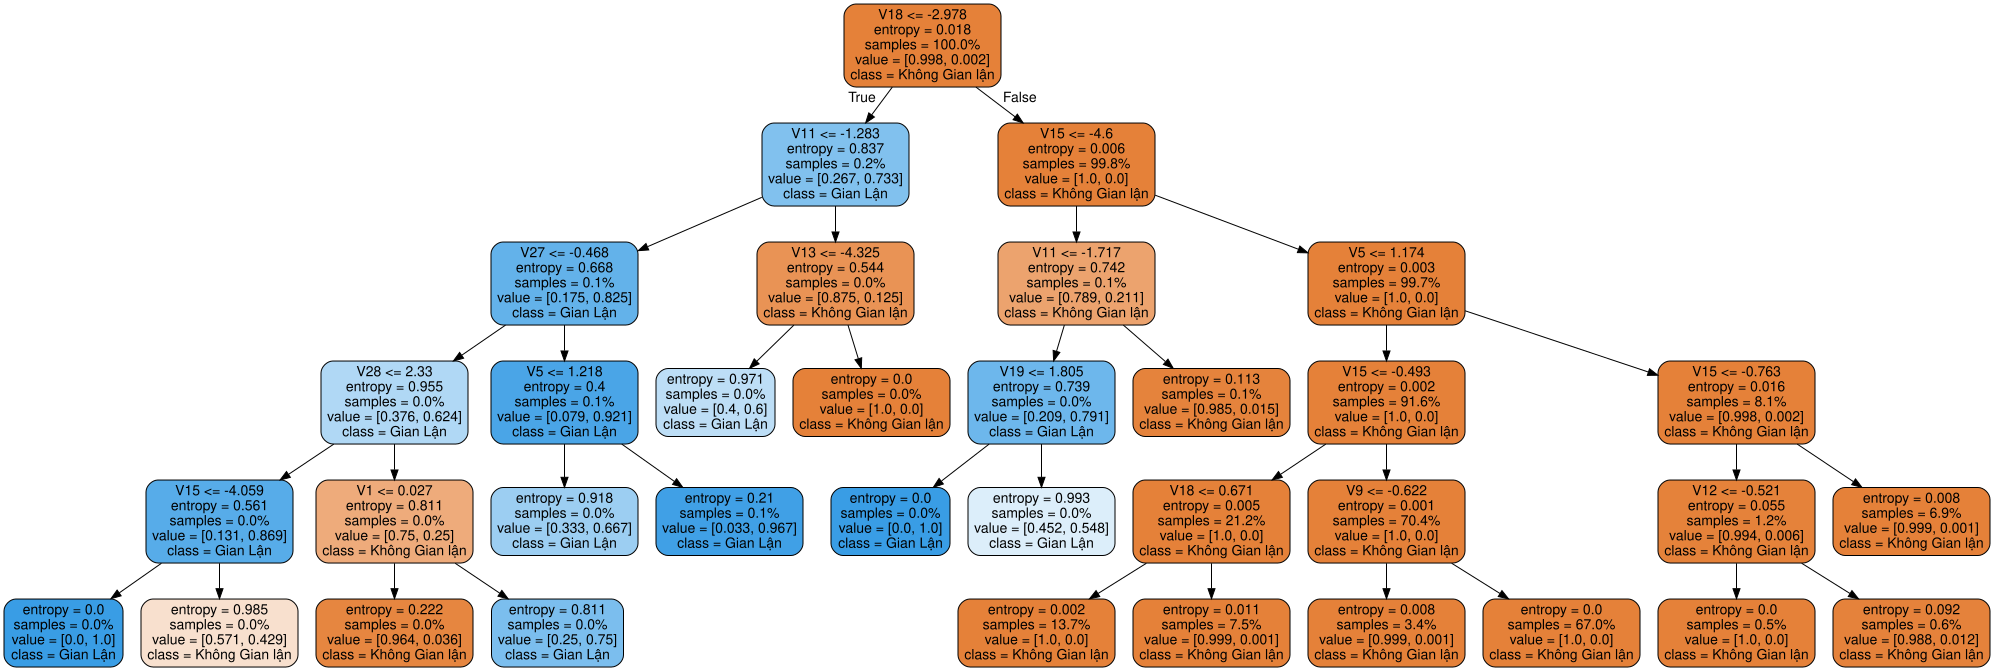

In [17]:
feature_names = x.columns


dot_data = tree.export_graphviz(
    dc_opt_tune[0],
    out_file=None,
    filled=True,
    rounded=True,
    feature_names=feature_names,
    class_names=['Không Gian lận', 'Gian Lận'],
    proportion=True
)

graph = graphviz.Source(dot_data)
graph

--- ĐÁNH GIÁ: DECISIONTREE ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.87      0.73      0.79        95

    accuracy                           1.00     56746
   macro avg       0.94      0.86      0.90     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC: 0.9133
PR-AUC (AUPRC): 0.7130 (Quan trọng cho Fraud)


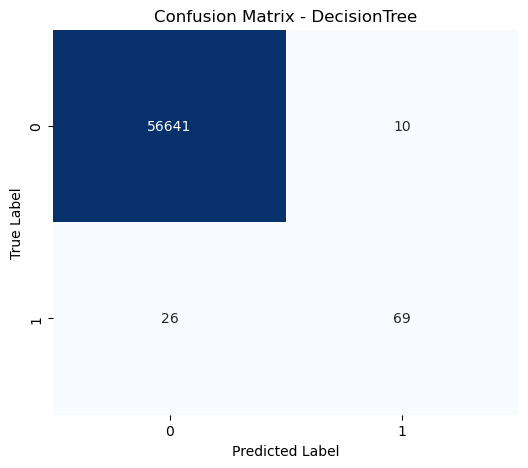

In [18]:
evaluate_model(dc_opt_tune[0],x_test,y_test,"DecisionTree")

In [19]:
dc_gcv_path = os.path.join(project_root,"configs","dc_rcv_raw.json")

In [20]:
dc_gcv_tune = tune_model(x_train,y_train,"dc","gcv",dc_gcv_path)

--- Bắt đầu Tuning DC bằng GCV ---
Fitting 5 folds for each of 1440 candidates, totalling 7200 fits

=== Kết quả Tuning ===
Best Params: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 6, 'min_samples_split': 2}
Best Score (f1): 0.8259


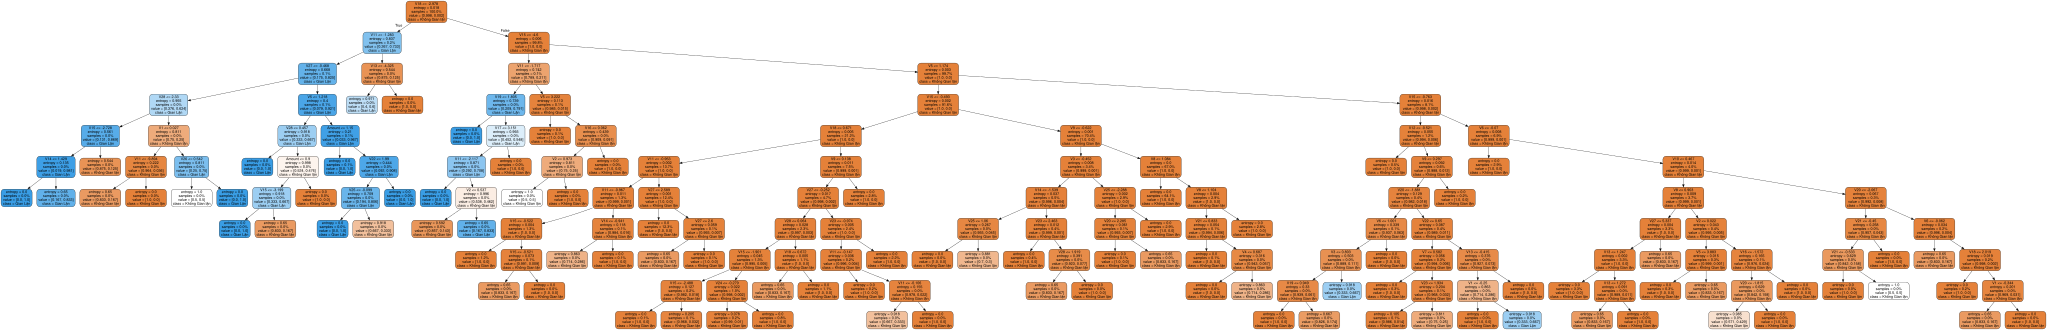

In [21]:
feature_names = x.columns


dot_data = tree.export_graphviz(
    dc_gcv_tune[0],
    out_file=None,
    filled=True,
    rounded=True,
    feature_names=feature_names,
    class_names=['Không Gian lận', 'Gian Lận'],
    proportion=True
)

graph = graphviz.Source(dot_data)
graph

--- ĐÁNH GIÁ: DECISIONTREE ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.82      0.71      0.76        95

    accuracy                           1.00     56746
   macro avg       0.91      0.85      0.88     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC: 0.8783
PR-AUC (AUPRC): 0.6871 (Quan trọng cho Fraud)


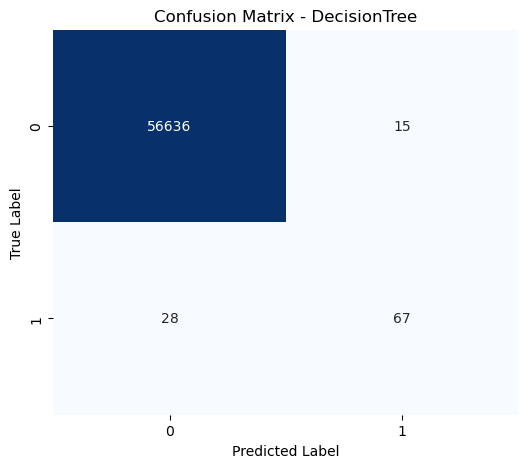

In [24]:
evaluate_model(dc_gcv_tune[0],x_test,y_test,"DecisionTree")

ở Dự liệu này ta sẽ lựa chọn mô hình có điểm PR-AUC cao nhất nên t sẽ chọn mô hình của optuna.

In [25]:
save_opt_path = os.path.join(project_root,"models","model_dc_opt.pkl")

In [26]:
save_model(dc_opt_tune,save_opt_path)

'Đã lưu model vào: d:\\PYTHON\\data_mining\\fraud-detecion-project\\models\\model_dc_opt.pkl '